In [47]:
import os
os.chdir(r"C:\Users\wangy")
import pandas as pd

In [48]:
# # Load your two datasets (replace with your actual file paths)
# df1 = pd.read_excel("wechat(S1)/detail_filtered2.xlsx")
# df2 = pd.read_excel("batch_outputs(S2)/filtered2_results_clustered_all.xlsx")

# # Filter out rows from df2 where article title appears in df1
# detail_diffusion = df1[df1['article_title'].isin(df2['Title'])]

# # Save the filtered dataset
# detail_diffusion.to_excel("diffusion(S3)/detail_diffusion.xlsx", index=False)

In [49]:
df=pd.read_excel("diffusion(S3)/detail_diffusion.xlsx")

In [50]:
df.head()

,detail_index,article_title,agent_name,reader_wechat_nn,reader_layer,reader_address,reader_gender,reader_time,reader_stay,reader_share2moment,reader_share2friend,reader_read,network_parent
0,1350,#名匠出品 必属精品#,赵林,赵·国际城G组团·负责专员,1,贵州贵阳,1,2017-09-28 05:36:14,0,0,0,3,NaN
1,1351,#名匠出品 必属精品#,赵林,完美love,1,上海,0,2017-08-23 05:54:00,0,0,0,1,NaN
2,1352,#名匠出品 必属精品#,赵林,琪琪,1,贵州贵阳,0,2017-08-22 21:55:05,30,0,0,1,NaN
3,1353,#名匠出品 必属精品#,赵林,陈俊东-名匠装饰-家装顾问,1,贵州贵阳,1,2017-08-23 05:55:17,0,0,0,1,NaN
4,1354,#名匠出品 必属精品#,赵林,丹,1,中国 贵州 贵阳,0,2017-08-23 05:56:55,0,0,0,1,NaN


In [51]:
len(df)

199154

**Preporcess before we start analysis**

In [52]:
import pandas as pd
from pathlib import Path

# ---- Edit file paths ----
path_agent_job= Path("diffusion(S3)/agent_dep_job.csv")      # HR info
path_agent_wechat= Path("diffusion(S3)/agent_wechatnn.csv")   # WeChat mapping
path_topic = Path("batch_outputs(S2)/filtered2_results_clustered_all.xlsx")

# ---- Load ----
agent_job = pd.read_csv(path_agent_job)
wechatnn = pd.read_csv(path_agent_wechat)
topics = pd.read_excel(path_topic)

In [53]:
merged = df.merge(
    topics[["Title", "TopContentCluster"]],
    left_on="article_title", right_on="Title",
    how="left"
)


In [54]:
len(merged)

199154

In [36]:
dep_filtered = agent_job.dropna(subset=['agent_dep', 'agent_job'])  # Removes rows with NULL values
dep_filtered = dep_filtered[dep_filtered['agent_dep'].str.strip() != ""]  # Removes rows with empty strings in agent_dep
dep_filtered = dep_filtered[dep_filtered['agent_job'].str.strip() != ""]  # Removes rows with empty strings in agent_job
dep_filtered = dep_filtered.rename(columns={'agent': 'agent_name'})

In [12]:
job_wechatnn = pd.merge(dep_filtered, wechatnn, on='agent_name', how='inner')
job_wechatnn.head()

,agent_name,agent_dep,agent_job,wechat_1,wechat_2,wechat_3
0,吴伟,地市营销总部岳阳营销部市场C组,家装顾问,名匠吴伟18073038361,NaN,NaN
1,蒋小村,望城店网销部长沙区,网络家装顾问,小聪,NaN,NaN
2,李云俊,星沙店市场部二区长沙区,市场部,A01名匠～李云龙17077468207,NaN,NaN
3,许源,地市营销总部常德城西营销部,市场部经理,MJ_许源,NaN,NaN
4,闵玲,城东店网络部长沙区,网销家装顾问,Minmin??,NaN,NaN


In [55]:
merged = merged.merge(
    agent_job[["agent", "agent_job"]],
    left_on="agent_name", right_on="agent",
    how="inner"
)

In [56]:
merged.shape

(201784, 17)

In [ ]:
merged = merged.merge(
    wechatnn[["agent_name", "wechat_1", "wechat_2", "wechat_3"]],
    left_on="agent_name", right_on="agent_name",
    how="left"
)

In [ ]:
merged.shape

**Update the reader_layer since some are agents that use their own account to read and share the article.**

In [31]:
import networkx as nx
nx.__version__

'3.5'

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

df = merged.copy()

# 1) Light cleanup (trim; keep real NaNs)
def _strip(x):
    return x if pd.isna(x) else str(x).strip()

for c in ["reader_wechat_nn","network_parent","wechat_1","wechat_2","wechat_3"]:
    if c in df.columns:
        df[c] = df[c].apply(_strip)

# Ensure numeric layer for fallback use
df["reader_layer"] = pd.to_numeric(df["reader_layer"], errors="coerce").fillna(0).astype(int)

# 2) Canonicalize node IDs: map agent aliases and layer==0 to the agent node
wechat_cols = [c for c in ["wechat_1","wechat_2","wechat_3"] if c in df.columns]

def _alias_set(row):
    return {row[c] for c in wechat_cols if pd.notna(row.get(c))}

def canon_reader(row):
    aliases = _alias_set(row)
    # self-read (layer 0) or reader is an alias → treat as the agent node
    if row["reader_layer"] == 0 or row["reader_wechat_nn"] in aliases:
        return row["agent_name"]
    return row["reader_wechat_nn"]

def canon_parent(row):
    if pd.isna(row.get("network_parent")):
        return np.nan
    aliases = _alias_set(row)
    # alias parent → agent
    if row["network_parent"] in aliases:
        return row["agent_name"]
    return row["network_parent"]

df["node_id"]   = df.apply(canon_reader, axis=1)
df["parent_id"] = df.apply(canon_parent,  axis=1)

# 3) Build observed graph per (agent, article) and compute BFS distance from agent
def compute_correct_layer(frame: pd.DataFrame) -> pd.DataFrame:
    g = frame.copy()
    agent = g["agent_name"].iloc[0]

    # Directed graph from observed edges only
    G = nx.DiGraph()
    G.add_node(agent)
    G.add_nodes_from(g["node_id"].astype(str))

    # agent → node for recorded layer==1
    e1 = [(agent, nid) for nid in g.loc[g["reader_layer"]==1, "node_id"].astype(str)]

    # parent → child for recorded layer>=2 (parent_id present)
    sub = g.loc[g["reader_layer"]>=2, ["parent_id","node_id"]].dropna(subset=["parent_id"])
    e2 = list(zip(sub["parent_id"].astype(str), sub["node_id"].astype(str)))

    G.add_edges_from(e1 + e2)

    # Undirected distances for layers
    UG = G.to_undirected()

    # Distances dict (agent=0). If agent isolated, at least {agent:0}.
    dist = nx.single_source_shortest_path_length(UG, agent) if agent in UG else {agent: 0}

    # Map distances; fill unreachable with original recorded layer; cast to int safely
    nid = g["node_id"].astype(str)
    mapped = nid.map(dist)                          # may contain NaN if unreachable
    fallback = g["reader_layer"]                    # already int from earlier
    g["correct_layer"] = mapped.fillna(fallback).astype(int)

    return g

df = (
    df.groupby(["agent_name","article_title"], sort=False, group_keys=False)
      .apply(compute_correct_layer)
      .reset_index(drop=True)
)

print("✅ Added column: correct_layer (BFS distance from agent on observed graph).")


In [ ]:
df.head()

In [ ]:
df.shape

In [78]:
df.query("agent_name == '赵林' and article_title.str.contains('#名匠出品 必属精品#')")[["article_title", "agent_name", "reader_wechat_nn", "network_parent", "reader_layer", "correct_layer"]
]

,article_title,agent_name,reader_wechat_nn,network_parent,reader_layer,correct_layer
0,#名匠出品 必属精品#,赵林,赵·国际城G组团·负责专员,NaN,1,0
1,#名匠出品 必属精品#,赵林,完美love,NaN,1,1
2,#名匠出品 必属精品#,赵林,琪琪,NaN,1,1
3,#名匠出品 必属精品#,赵林,陈俊东-名匠装饰-家装顾问,NaN,1,1
4,#名匠出品 必属精品#,赵林,丹,NaN,1,1
5,#名匠出品 必属精品#,赵林,刘行恩·名匠装饰18373832827,NaN,1,1
6,#名匠出品 必属精品#,赵林,??MJ·陆文俊,NaN,1,1
7,#名匠出品 必属精品#,赵林,邓春.名匠装饰.主任设计师,NaN,1,1
8,#名匠出品 必属精品#,赵林,李扬-名匠装饰-家装顾问,NaN,1,1
9,#名匠出品 必属精品#,赵林,金牌标榜张平18786622376,NaN,1,1


In [79]:
df.query("agent_name == '吴梦娇' and article_title.str.contains('110平方')")[["article_title", "agent_name", "reader_wechat_nn", "network_parent", "reader_layer", "correct_layer"]
]

,article_title,agent_name,reader_wechat_nn,network_parent,reader_layer,correct_layer
18,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,MJ～吴梦娇,NaN,1,0
19,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,海,MJ～吴梦娇,2,1
20,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,申瑞特 黄俊博,MJ～吴梦娇,2,1
21,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,赵猛,MJ～吴梦娇,2,1
22,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,莲,MJ～吴梦娇,2,1
23,#名匠出品 必属精品#[玫瑰] 面积：110平方,吴梦娇,流水知音,MJ～吴梦娇,2,1


In [77]:
df.query("agent_name == '何纯勇' and article_title.str.contains('10大主流')")[["article_title", "agent_name", "reader_wechat_nn", "network_parent", "reader_layer", "correct_layer"]
]

,article_title,agent_name,reader_wechat_nn,network_parent,reader_layer,correct_layer
411,10大主流装修风格详解，你喜欢哪个范？,何纯勇,名匠装饰·何东,NaN,1,0
412,10大主流装修风格详解，你喜欢哪个范？,何纯勇,MJ~左都美,NaN,1,1
413,10大主流装修风格详解，你喜欢哪个范？,何纯勇,【千里湖山】李进伟,NaN,1,1
414,10大主流装修风格详解，你喜欢哪个范？,何纯勇,加油@自己,NaN,1,1
415,10大主流装修风格详解，你喜欢哪个范？,何纯勇,??特困户??,NaN,1,1
416,10大主流装修风格详解，你喜欢哪个范？,何纯勇,ping-p,NaN,1,1
417,10大主流装修风格详解，你喜欢哪个范？,何纯勇,O(∩_∩)O,NaN,1,1
418,10大主流装修风格详解，你喜欢哪个范？,何纯勇,不负好时光,NaN,1,1
419,10大主流装修风格详解，你喜欢哪个范？,何纯勇,陈琳,NaN,1,1
420,10大主流装修风格详解，你喜欢哪个范？,何纯勇,MJ-设计师彭黎君,NaN,1,1


In [80]:
df['correct_layer'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7, 10,  9, 11,  8, 12, 13, 14, 15, 16,
       17, 19, 21, 18, 22, 23])

In [81]:
df.to_excel("diffusion(S3)/diffusion_corrected_layers.xlsx", index=False)

In [82]:
df['reader_gender'].unique()

array([1, 0])

In [2]:
import pandas as pd

df = pd.read_excel("diffusion(S3)/diffusion_corrected_layers.xlsx")
unique_agents = df['agent_name'].dropna().unique()
print(len(unique_agents))
unique_agents_df = pd.DataFrame(unique_agents, columns=['agent_name'])
unique_agents_df.to_excel("diffusion(S3)/unique_agents.xlsx", index=False)

print(f"✅ Saved {len(unique_agents_df)} unique agents to unique_agents.xlsx")

592
✅ Saved 592 unique agents to unique_agents.xlsx


In [17]:
df.shape

(201014, 22)

In [12]:
import pandas as pd
from pathlib import Path
path_topic = Path("batch_outputs(S2)/filtered2_results_clustered_all.xlsx")
topics = pd.read_excel(path_topic)

agents = pd.read_excel("diffusion(S3)/unique_agentsgender.xlsx")  # contains agent_name, gender
diffusion = pd.read_excel("diffusion(S3)/diffusion_corrected_layers.xlsx")

# Step 2: Merge on agent_name
merged = diffusion.merge(agents, on="agent_name", how="left")
merged= merged.drop(columns=["TopContentCluster"])

In [14]:
merged.head()

,detail_index,article_title,agent_name,reader_wechat_nn,reader_layer,reader_address,reader_gender,reader_time,reader_stay,reader_share2moment,...,network_parent,Title,agent_job,wechat_1,wechat_2,wechat_3,node_id,parent_id,correct_layer,agent_gender
0,1350,#名匠出品 必属精品#,赵林,赵·国际城G组团·负责专员,1,贵州贵阳,1,2017-09-28 05:36:14,0,0,...,NaN,#名匠出品 必属精品#,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,赵林,NaN,0,1
1,1351,#名匠出品 必属精品#,赵林,完美love,1,上海,0,2017-08-23 05:54:00,0,0,...,NaN,#名匠出品 必属精品#,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,完美love,NaN,1,1
2,1352,#名匠出品 必属精品#,赵林,琪琪,1,贵州贵阳,0,2017-08-22 21:55:05,30,0,...,NaN,#名匠出品 必属精品#,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,琪琪,NaN,1,1
3,1353,#名匠出品 必属精品#,赵林,陈俊东-名匠装饰-家装顾问,1,贵州贵阳,1,2017-08-23 05:55:17,0,0,...,NaN,#名匠出品 必属精品#,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,陈俊东-名匠装饰-家装顾问,NaN,1,1
4,1354,#名匠出品 必属精品#,赵林,丹,1,中国 贵州 贵阳,0,2017-08-23 05:56:55,0,0,...,NaN,#名匠出品 必属精品#,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN,丹,NaN,1,1


In [15]:
merged = merged.merge(
    topics[["Title", "家居设计与装修(Content)", "房地产与建筑(Content)", "活动与促销(Content)", 
            "品牌与市场推广(Content)", "生活方式与文化(Content)", "客户服务与管理(Content)"]],
    on= "Title",
    how="left"
)

# Step 3: Save to a new Excel file
merged.to_excel("diffusion(S3)/diffusion_genderTopicvector.xlsx", index=False)

print(f"✅ Merged dataset saved as diffusion_with_gender.xlsx with shape {merged.shape}")

✅ Merged dataset saved as diffusion_with_gender.xlsx with shape (201014, 28)


In [83]:
# 0) Load data
data = pd.read_excel("diffusion(S3)/diffusion_corrected_layers.xlsx")

# Ensure numeric types we use later
data["correct_layer"] = pd.to_numeric(data["correct_layer"], errors="coerce").fillna(0).astype(int)
for c in ["reader_share2moment","reader_share2friend","reader_stay","reader_read"]:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

# Optional trim (safe; preserves NaN)
def _strip(x):
    return x if pd.isna(x) else str(x).strip()
for c in ["reader_wechat_nn","network_parent","TopContentCluster","agent_name","article_title"]:
    if c in data.columns:
        data[c] = data[c].apply(_strip)

# 1) Fill agent gender on layer==0 (using correct_layer)
if "agent_gender" in data.columns:
    agent_gender_map = (
        data[["agent_name","agent_gender"]]
        .drop_duplicates("agent_name")
        .set_index("agent_name")["agent_gender"]
    )
else:
    self_rows = data.loc[(data["correct_layer"] == 0) & (data["reader_gender"].notna()),
                         ["agent_name","reader_gender"]]
    agent_gender_map = self_rows.groupby("agent_name", as_index=True)["reader_gender"].first()

mask_layer0 = data["correct_layer"] == 0
data.loc[mask_layer0, "reader_gender"] = data.loc[mask_layer0, "agent_name"].map(agent_gender_map)

In [84]:
# 2) Convenience columns
data["duration_seconds"] = data["reader_stay"].fillna(0) * 15
data["reshare_flag"] = (data["reader_share2moment"].fillna(0).astype(int) == 1) | \
                       (data["reader_share2friend"].fillna(0).astype(int) == 1)
data["cascade_key"] = list(zip(data["agent_name"], data["article_title"]))
grp = data.groupby("cascade_key", sort=False)

# 3) Vectorized metrics (widths, depth, reshare, durations, topic, gender %)
first_layer_width  = grp["correct_layer"].apply(lambda s: (s==1).sum()).rename("first_layer_width")
second_layer_width = grp["correct_layer"].apply(lambda s: (s==2).sum()).rename("second_layer_width")
depth              = grp["correct_layer"].max().fillna(0).astype(int).rename("depth")

# Audience-only reshare % (exclude layer 0; 1 row per person per cascade)
aud = data[data["correct_layer"] >= 1].copy()
person = (aud.groupby(["cascade_key","reader_wechat_nn"], as_index=False)
              .agg(reshared=("reshare_flag","max")))
reshare_pct = (person.groupby("cascade_key")["reshared"]
                     .mean()
                     .rename("reshare_pct"))

duration_mean = grp["duration_seconds"].mean().fillna(0).rename("duration_mean_s")
duration_var  = grp["duration_seconds"].var(ddof=1).fillna(0).rename("duration_var_s2")

topic_id = grp["TopContentCluster"].agg(lambda s: s.dropna().iloc[0] if s.dropna().size else np.nan) \
                                  .rename("article_topic")

gender_counts = grp["reader_gender"].value_counts(dropna=False).unstack(fill_value=0)
gender_pct = (gender_counts.T / gender_counts.sum(axis=1)).T
gender_pct.columns = [f"gender_pct_{col}" for col in gender_pct.columns]

# 4) Graph metrics (centralization, structural virality, assortativity, node centralities)
def graph_metrics(frame: pd.DataFrame) -> pd.Series:
    agent = frame["agent_name"].iloc[0]

    # Directed cascade graph from correct_layer
    G = nx.DiGraph()
    G.add_node(agent)
    G.add_nodes_from(frame["reader_wechat_nn"].astype(str))

    # agent -> reader for layer==1
    e1 = [(agent, r) for r in frame.loc[frame["correct_layer"]==1, "reader_wechat_nn"].astype(str)]
    # parent -> child for layer>=2 (require a parent value)
    sub2 = frame.loc[frame["correct_layer"]>=2, ["network_parent","reader_wechat_nn"]].dropna(subset=["network_parent"])
    e2 = list(zip(sub2["network_parent"].astype(str), sub2["reader_wechat_nn"].astype(str)))
    G.add_edges_from(e1 + e2)

    n_dir = G.number_of_nodes()
    m_dir = G.number_of_edges()

    # Agent node out-degree centrality (0..1)
    try:
        agent_deg_cent = nx.out_degree_centrality(G).get(agent, 0.0)
    except Exception:
        agent_deg_cent = 0.0

    # Average out-degree centrality = m / (n*(n-1))
    avg_deg_cent = 0.0 if n_dir < 2 else m_dir / (n_dir * (n_dir - 1))

    # Freeman out-degree centralization (graph-level)
    out_deg = dict(G.out_degree())
    if n_dir <= 2:
        centralization = 0.0
    else:
        max_deg = max(out_deg.values()) if out_deg else 0
        numer = sum(max_deg - d for d in out_deg.values())
        denom = (n_dir - 1) * (n_dir - 2)
        centralization = numer / denom if denom > 0 else 0.0

    # Undirected LCC for distances/assortativity
    UG = G.to_undirected()
    if UG.number_of_edges() == 0:
        return pd.Series({
            "centrality": centralization,
            "wiener_index": 0.0,
            "structural_virality": np.nan,
            "gender_assortativity": np.nan,
            "agent_deg_centrality": agent_deg_cent,
            "avg_out_degree_centrality": avg_deg_cent
        })

    lcc_nodes = max(nx.connected_components(UG), key=len)
    H = UG.subgraph(lcc_nodes).copy()

    # Wiener index (sum of all-pairs shortest paths over i<j)
    nodes = list(H.nodes())
    nn = len(nodes)
    spl = dict(nx.all_pairs_shortest_path_length(H))
    wsum = 0
    for i in range(nn):
        li = spl[nodes[i]]
        for j in range(i+1, nn):
            wsum += li[nodes[j]]
    wiener = float(wsum)

    # Structural virality ν = 2*W / (nn*(nn-1)) using nn from H
    structural_virality = np.nan if nn < 2 else (2.0 * wiener) / (nn * (nn - 1))

    # Gender assortativity (strict: both endpoints known)
    agent_gender_series = frame.loc[frame["correct_layer"]==0, "reader_gender"].dropna()
    agent_gender = agent_gender_series.iloc[0] if not agent_gender_series.empty else np.nan

    node_gender = {str(r): g for r, g in zip(frame["reader_wechat_nn"].astype(str), frame["reader_gender"])}
    node_gender[str(agent)] = agent_gender
    nx.set_node_attributes(H, node_gender, "gender")

    eligible_edges, genders_seen = [], set()
    for u, v in H.edges():
        gu = H.nodes[u].get("gender", np.nan)
        gv = H.nodes[v].get("gender", np.nan)
        if (gu is not None) and (gv is not None) and (not pd.isna(gu)) and (not pd.isna(gv)):
            eligible_edges.append((u, v))
            genders_seen.update([gu, gv])

    if (len(eligible_edges) == 0) or (len(genders_seen) < 2):
        assort = np.nan
    else:
        with np.errstate(invalid='ignore', divide='ignore'):
            assort = nx.attribute_assortativity_coefficient(H.edge_subgraph(eligible_edges), "gender")

    return pd.Series({
        "centrality": centralization,
        "wiener_index": wiener,
        "structural_virality": structural_virality,
        "gender_assortativity": assort,
        "agent_deg_centrality": agent_deg_cent,
        "avg_out_degree_centrality": avg_deg_cent
    })

graph_df = grp.apply(graph_metrics)

# 5) Assemble & save
out = pd.concat(
    [first_layer_width, second_layer_width, depth, reshare_pct,
     graph_df, duration_mean, duration_var],
    axis=1
).join(gender_pct, how="left").join(topic_id, how="left")

out[["agent_name","article_title"]] = pd.DataFrame(out.index.tolist(), index=out.index)
out = out.reset_index(drop=True)

cols = [
    "agent_name","article_title","article_topic",
    "first_layer_width","second_layer_width","depth",
    "reshare_pct","centrality","wiener_index","structural_virality",
    "gender_assortativity","agent_deg_centrality","avg_out_degree_centrality",
    "duration_mean_s","duration_var_s2"
] + [c for c in out.columns if c.startswith("gender_pct_")]
out = out.reindex(columns=[c for c in cols if c in out.columns])

C:\Users\wangy\AppData\Local\Temp\ipykernel_20696\3085838901.py:129: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  graph_df = grp.apply(graph_metrics)


In [85]:
out.head()

,agent_name,article_title,article_topic,first_layer_width,second_layer_width,depth,reshare_pct,centrality,wiener_index,structural_virality,gender_assortativity,agent_deg_centrality,avg_out_degree_centrality,duration_mean_s,duration_var_s2,gender_pct_1,gender_pct_0
0,赵林,#名匠出品 必属精品#,家居设计与装修,17,0,1,0.000000,1.000000,289.0,1.888889,-0.259259,0.944444,0.049708,150.000000,1.191176e+05,0.611111,0.388889
1,吴梦娇,#名匠出品 必属精品#[玫瑰] 面积：110平方,家居设计与装修,5,0,1,0.000000,1.000000,25.0,1.666667,-0.666667,0.833333,0.119048,375.000000,3.375000e+04,0.666667,0.333333
2,周志刚,108㎡优雅灰色装饰，考古、机械爱好者的家，真酷！,家居设计与装修,60,78,2,0.028986,0.426708,6652.0,2.754451,-0.200000,0.428571,0.013883,1105.714286,2.531795e+07,0.671429,0.328571
3,龙海,10大主流装修风格详解，你喜欢哪个范？,家居设计与装修,31,46,3,0.051948,0.368631,8618.0,2.869797,0.017021,0.371795,0.012496,867.073171,1.003902e+06,0.390244,0.609756
4,吴灿,10大主流装修风格详解，你喜欢哪个范？,家居设计与装修,88,24,3,0.050505,0.752525,11817.0,2.387273,-0.351351,0.747475,0.010000,939.823009,1.220632e+06,0.407080,0.592920


In [89]:
out_path = "diffusion(S3)/analyzed1_diffusion.xlsx"
out.to_excel(out_path, index=False)

In [27]:
data["agent_job"].unique()

array(['市场区域经理', '家装顾问', '区域经理（勇士队）', '网络主管', '网销家装顾问', '网络家装顾问', '网销组长',
       '市场部', '网络部', '网络客服经理', '营销总监', '区域经理', 'VIP经理', '大区经理', '片区经理',
       'VIP家装顾问', '金牌家装顾问', '网络部客服经理', '网络部组长', '文案策划', '市场部经理', '一片区区经理',
       '网路销售员', '电商', '网络部主管', 'IT营销总监', '网销顾问', '首席设计师', '电器销售', '主任设计师',
       '电商部主管', '客服', '区域经理（战神队）', '二片区区经理', '区域经理（狼之队）', '一片区经理',
       '区域经理（精英队）', '区域经理（威武队）', '经理（火狼队）', '二片区经理', '区域经理（雷霆战队）',
       '区域经理（奋进组）', '市场总监', '店长', '长沙营销总监', '店总经理', '首席', '高级设计师',
       '区域经理（野狼组）', '区域经理（非凡组）', '经理（签单队）', '区域经理（狂魔队）', '经理（高级）', '醴陵',
       '（设计部经理)首席设计师', '区域经理（猎鹰部）', '营销部总经理', '网络客服', '电商品推主管', '地市营销总部',
       '资深家装顾问', '网络客服主管', '经理（首席）', '总经理', '总经理/国庆店总经理', '总经理/华新店总经理',
       '高级设计部', '运营总监', '经理（首席设计师）', '经理（首席)', '总经理/东店总经理', '名匠地市副总裁',
       '区域经理（超神队）'], dtype=object)

In [90]:
out["gender_assortativity"].isna().sum()

np.int64(2785)

In [91]:
# 1) Cascades where gender_assortativity is NaN
na_cascades = out[out["gender_assortativity"].isna()].copy()

# 2) See each cascade’s max layer (it's already the 'depth' column)
na_cascades_maxlayer = na_cascades[["agent_name","article_title","depth"]]
print(na_cascades_maxlayer.head())


   agent_name        article_title  depth
22         钱进  10大主流装修风格详解，你喜欢哪个范？      1
23         杨州  10大主流装修风格详解，你喜欢哪个范？      1
24        简学良  10大主流装修风格详解，你喜欢哪个范？      1
28        李发扬  10大主流装修风格详解，你喜欢哪个范？      3
29        胡善国  10大主流装修风格详解，你喜欢哪个范？      1
depth
0     756
1    1853
2     155
3      15
4       6
Name: num_cascades, dtype: int64


In [ ]:
data = pd.read_excel("diffusion(S3)/diffusion_corrected_layers.xlsx")

In [22]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def plot_network_propagation(data, title, agent, save_path="network_graph.png", figsize=(12, 12), dpi=500):
    """
    Plot network propagation graph for a given title and agent.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing the network data
    title : str
        Article title to filter
    agent : str
        Agent name to filter
    save_path : str, optional
        Path to save the output image (default: "network_graph.png")
    figsize : tuple, optional
        Figure size (default: (12, 12))
    dpi : int, optional
        Resolution for saved image (default: 500)
    
    Returns:
    --------
    G : networkx.Graph
        The generated network graph
    """
    
    # Filter data for the selected title and agent
    data_filtered = data[(data['article_title'] == title) & (data['agent_name'] == agent)]
    
    if len(data_filtered) == 0:
        print(f"No data found for title='{title}' and agent='{agent}'")
        return None
    
    # Create the graph
    G = nx.Graph()
    
    # Add the root node (agent)
    G.add_node(agent)
    
    # Color scheme
    color_list = ['firebrick', 'teal', 'tan', 'cornflowerblue', 'salmon', 
                  'olive', 'rosybrown', 'plum', 'gold', 'peru', 'skyblue']
    
    # Initialize lists
    visited = []
    layer_list = []
    node_color = ['firebrick']  # Root node color
    
    # Get max layer
    max_layer = int(data_filtered['correct_layer'].max())
    
    # Build the network - start from layer 1 (skip layer 0 readers)
    for layer in range(1, max_layer + 1):
        for index, row in data_filtered.iterrows():
            wechat_nn = row['reader_wechat_nn']
            
            # Skip if already visited or if wechat_nn is NaN
            if pd.isna(wechat_nn) or wechat_nn in visited:
                continue
                
            if row['correct_layer'] == layer:
                if layer == 1:
                    # Layer 1: connect directly to agent
                    G.add_node(wechat_nn, layer=layer)
                    G.add_edge(wechat_nn, agent)
                    node_color.append(color_list[layer % len(color_list)])
                    layer_list.append(layer)
                else:
                    # Other layers: connect to parent
                    parent = row['network_parent']
                    
                    # If parent is NaN or not in graph, connect to agent
                    if pd.isna(parent) or parent not in G.nodes():
                        parent = agent
                    
                    try:
                        parent_layer = layer_list[visited.index(parent)] if parent in visited else layer - 1
                    except:
                        parent_layer = layer - 1
                    
                    G.add_node(wechat_nn, layer=parent_layer)
                    G.add_edge(wechat_nn, parent)
                    node_color.append(color_list[layer % len(color_list)])
                    layer_list.append(parent_layer)
                
                visited.append(wechat_nn)
    
    # Set node sizes (root node larger, others smaller)
    node_size = [100] + [20] * (len(G.nodes()) - 1)
    
    # Draw the graph
    plt.figure(figsize=figsize)
    nx.draw_spring(G, 
                   node_color=node_color, 
                   edge_color='lightgray', 
                   node_size=node_size,
                   with_labels=False,
                   alpha=0.8)
    
    plt.title(f'Network Propagation: {title}\nAgent: {agent}', fontsize=14, pad=20)
    plt.axis('off')
    
    # Save the figure
    plt.savefig(save_path, format="PNG", dpi=dpi, facecolor='w', bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print(f"Title: {title}")
    print(f"Agent: {agent}")
    print(f"Total nodes: {len(G.nodes())}")
    print(f"Total edges: {len(G.edges())}")
    print(f"Max layer: {max_layer}")
    
    return G

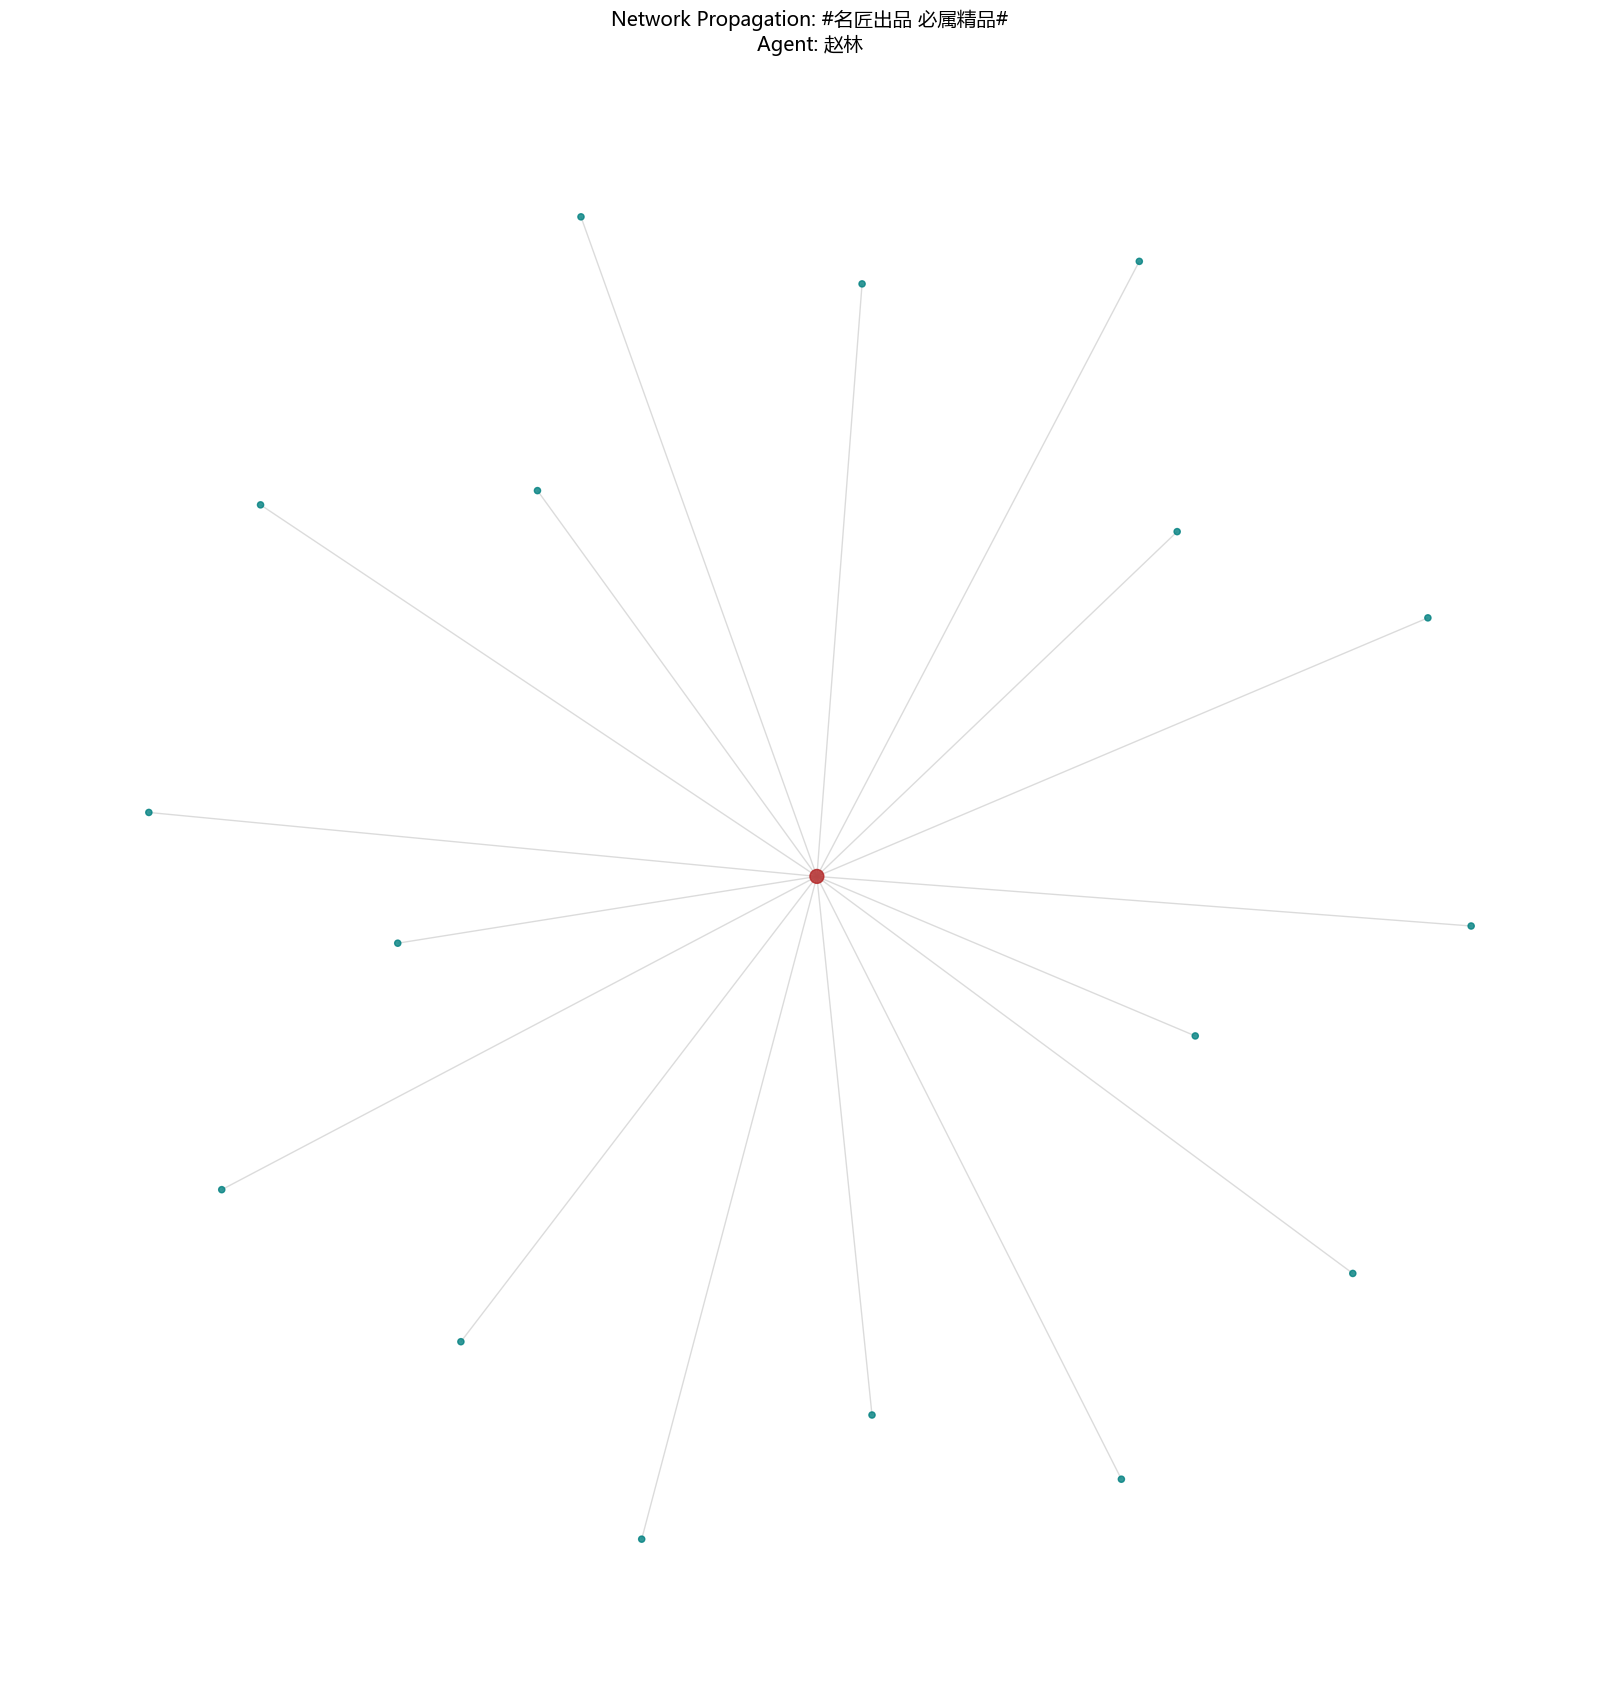

Title: #名匠出品 必属精品#
Agent: 赵林
Total nodes: 18
Total edges: 17
Max layer: 1


In [23]:
G = plot_network_propagation(data, 
                              title='#名匠出品 必属精品#', 
                              agent='赵林',
                              save_path="diffusion(S3)/zhaolin.png",
                              figsize=(16, 16),
                              dpi=300)

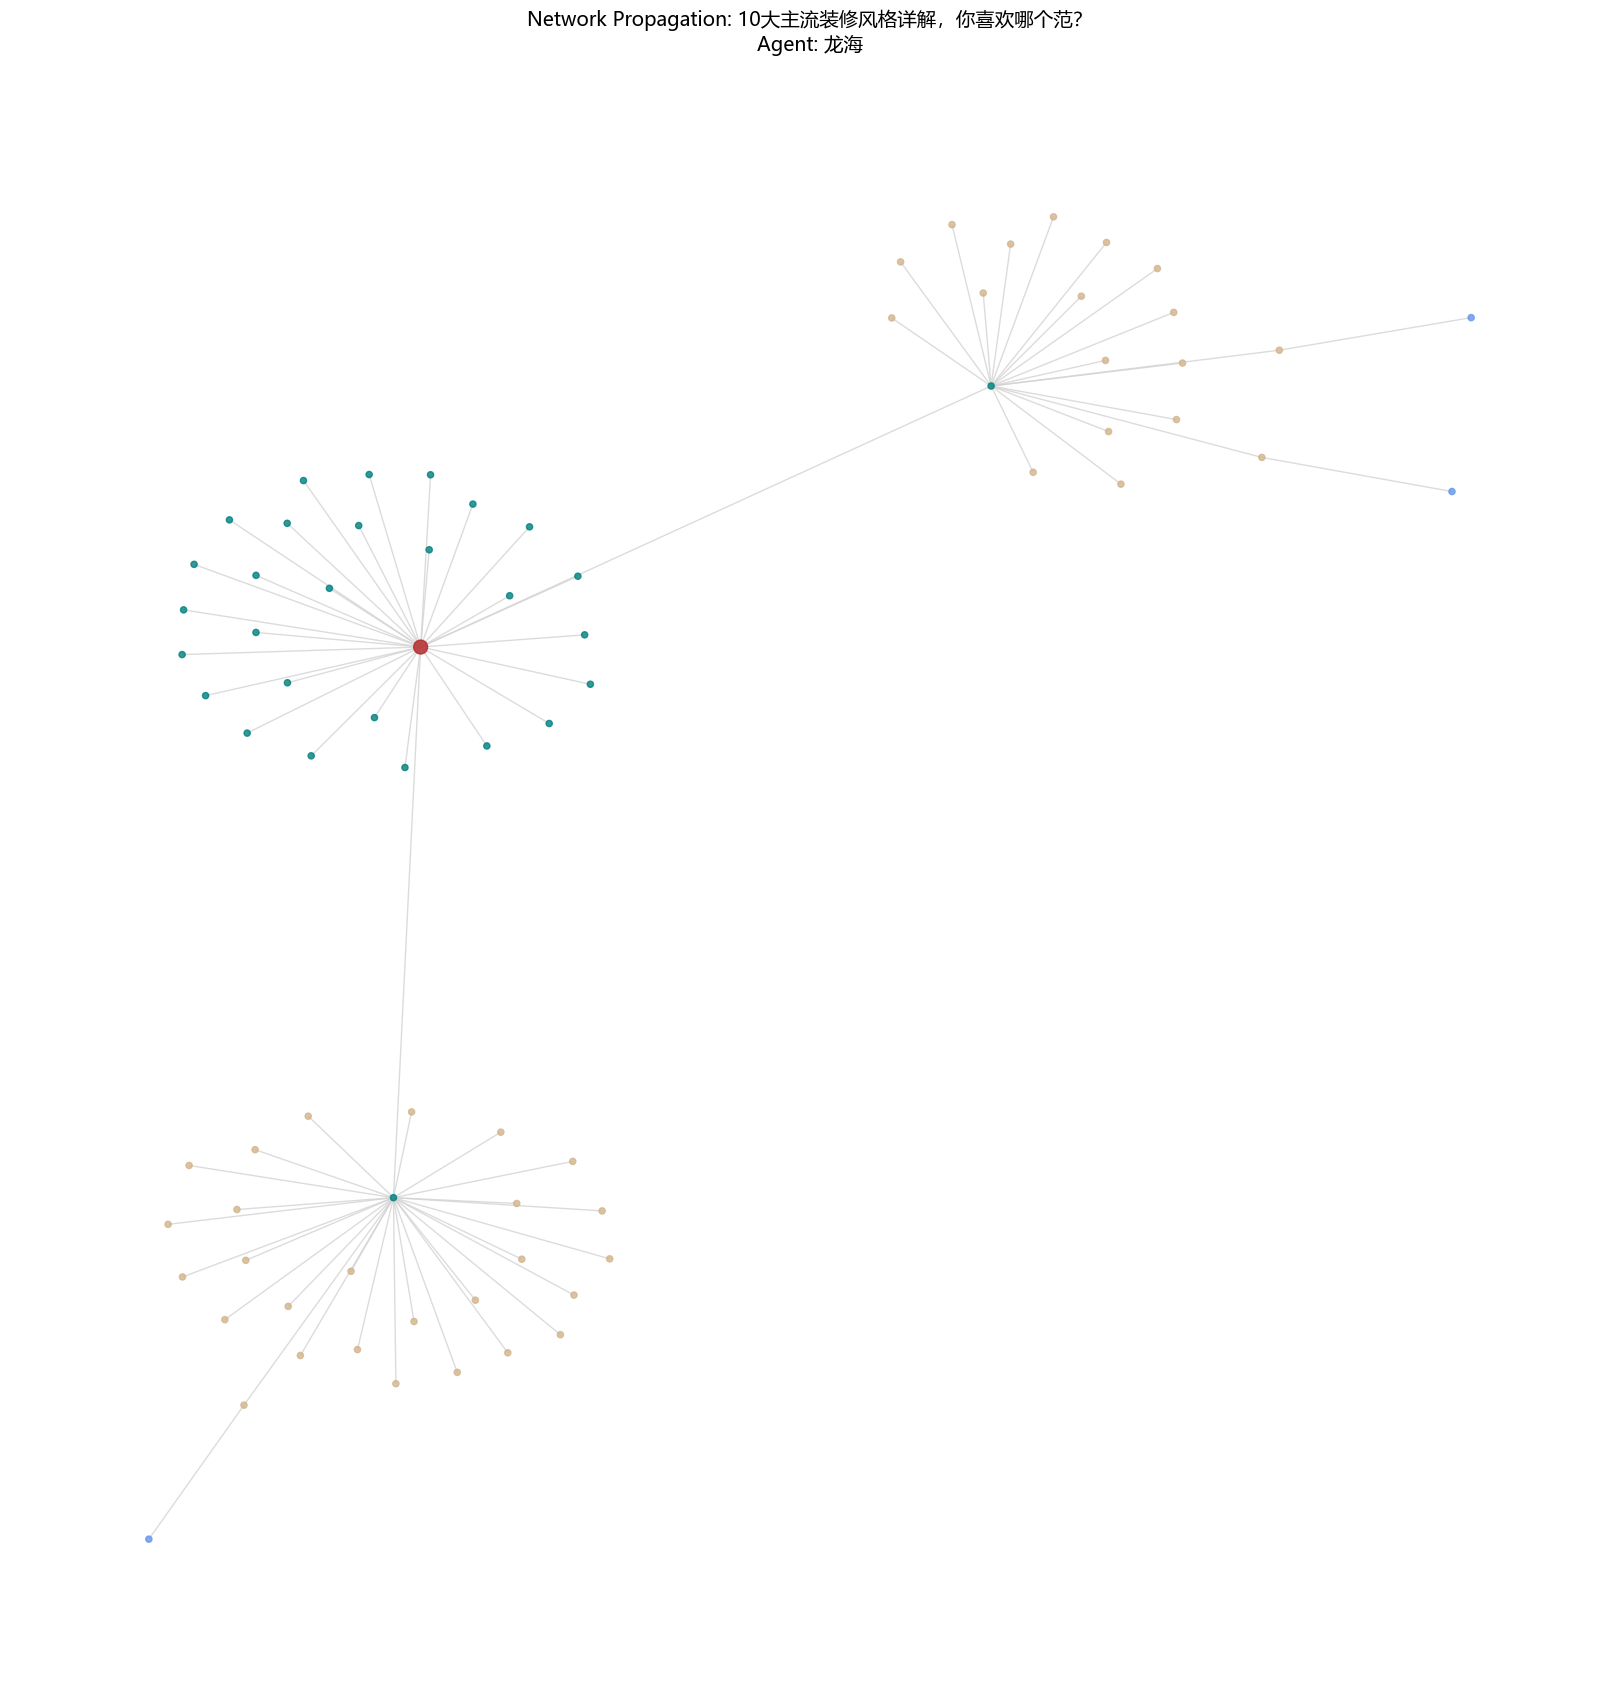

Title: 10大主流装修风格详解，你喜欢哪个范？
Agent: 龙海
Total nodes: 78
Total edges: 77
Max layer: 3


In [24]:
G = plot_network_propagation(data, 
                              title='10大主流装修风格详解，你喜欢哪个范？', 
                              agent='龙海',
                              save_path="diffusion(S3)/longhai.png",
                              figsize=(16, 16),
                              dpi=300)

In [57]:
import pandas as pd
import numpy as np
import os
os.chdir(r"C:\Users\wangy")

df=pd.read_excel("diffusion(S3)/detail_diffusion.xlsx")
df0 = df.copy()  # your original diffusion (199,154 rows)

# --- Normalize keys (strip; keep NaN as NaN) ---
def norm_str(s):
    s = pd.Series(s, dtype="string").str.strip()
    return s.mask(s.eq(""))

df0["agent_name"]    = norm_str(df0["agent_name"])
df0["article_title"] = norm_str(df0["article_title"])
agent_job["agent_name"] = norm_str(agent_job.get("agent", agent_job.get("agent_name")))
agent_job = agent_job.rename(columns={"agent":"agent_name"})
wechatnn["agent_name"]  = norm_str(wechatnn["agent_name"])
topics["Title"]         = norm_str(topics["Title"])

# --- Topics: 1 row per Title, then map ---
topics_1 = (topics
            .drop_duplicates("Title", keep="first")
            .set_index("Title")["TopContentCluster"])
df0["TopContentCluster"] = df0["article_title"].map(topics_1)

# --- Jobs: 1 row per agent, then map columns one by one ---
jobs_1 = (agent_job
          .dropna(subset=["agent_dep","agent_job"])
          .loc[lambda d: d["agent_dep"].astype("string").str.strip().ne("")]
          .loc[lambda d: d["agent_job"].astype("string").str.strip().ne("")]
          .drop_duplicates("agent_name", keep="first")
          .set_index("agent_name"))

for col in ["agent_dep","agent_job"]:
    df0[col] = df0["agent_name"].map(jobs_1[col])

# --- WeChat names: collapse to a single row per agent, then map ---
def first_nonnull(s):
    s = s.dropna().astype("string").str.strip()
    s = s[s.ne("")]
    return s.iloc[0] if len(s) else np.nan

wechat_cols = [c for c in ["wechat_1","wechat_2","wechat_3"] if c in wechatnn.columns]
if wechat_cols:
    wechat_1 = (wechatnn.groupby("agent_name")[wechat_cols]
                .agg(first_nonnull))                       # 1 row per agent
else:
    # long form (agent_name, wechat_nn)
    wechatnn["wechat_nn"] = norm_str(wechatnn["wechat_nn"])
    pack = (wechatnn.dropna(subset=["wechat_nn"])
                    .groupby("agent_name")["wechat_nn"]
                    .apply(lambda s: pd.unique(s)[:3]).to_dict())
    def pick(i): 
        return {a: (arr[i] if len(arr)>i else np.nan) for a,arr in pack.items()}
    wechat_1 = pd.DataFrame({"wechat_1":pick(0), "wechat_2":pick(1), "wechat_3":pick(2)})

for col in ["wechat_1","wechat_2","wechat_3"]:
    if col in wechat_1.columns:
        df0[col] = df0["agent_name"].map(wechat_1[col])

# --- Sanity: row count unchanged; index preserved ---
assert len(df0) == len(df), "Row count changed — mapping should not do that."


In [59]:
# --- fix agent_job columns to ensure 'agent_name' is unique ---
aj = agent_job.copy()

# If both 'agent' and 'agent_name' exist, coalesce then drop 'agent'
if 'agent' in aj.columns and 'agent_name' in aj.columns:
    aj['agent_name'] = aj['agent_name'].fillna(aj['agent'])
    aj = aj.drop(columns=['agent'])
elif 'agent' in aj.columns:
    aj = aj.rename(columns={'agent':'agent_name'})

# Drop any duplicate columns that share the same header
if aj.columns.duplicated().any():
    dup_cols = aj.columns[aj.columns.duplicated()]
    print("Dropping duplicate columns from agent_job:", list(dup_cols))
    aj = aj.loc[:, ~aj.columns.duplicated()]

print("Row count (should equal original df):", len(merged), "vs", len(df))


Dropping duplicate columns from agent_job: ['agent_name']
Row count (should equal original df): 199154 vs 199154


In [62]:
merged = (df
  .merge(topics.drop_duplicates("Title")[["Title","TopContentCluster"]],
         left_on="article_title", right_on="Title", how="left", validate="m:1")
  .merge(aj.drop_duplicates("agent_name")[["agent_name","agent_dep","agent_job"]],
         on="agent_name", how="left", validate="m:1")
  .merge(wechat_1.reset_index(),  # from the collapse step above
         on="agent_name", how="left", validate="m:1")
)
assert len(merged) == len(df)


In [64]:
len(merged)

199154

In [65]:
merged.head()

,detail_index,article_title,agent_name,reader_wechat_nn,reader_layer,reader_address,reader_gender,reader_time,reader_stay,reader_share2moment,reader_share2friend,reader_read,network_parent,Title,TopContentCluster,agent_dep,agent_job,wechat_1,wechat_2,wechat_3
0,1350,#名匠出品 必属精品#,赵林,赵·国际城G组团·负责专员,1,贵州贵阳,1,2017-09-28 05:36:14,0,0,0,3,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
1,1351,#名匠出品 必属精品#,赵林,完美love,1,上海,0,2017-08-23 05:54:00,0,0,0,1,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
2,1352,#名匠出品 必属精品#,赵林,琪琪,1,贵州贵阳,0,2017-08-22 21:55:05,30,0,0,1,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
3,1353,#名匠出品 必属精品#,赵林,陈俊东-名匠装饰-家装顾问,1,贵州贵阳,1,2017-08-23 05:55:17,0,0,0,1,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
4,1354,#名匠出品 必属精品#,赵林,丹,1,中国 贵州 贵阳,0,2017-08-23 05:56:55,0,0,0,1,NaN,#名匠出品 必属精品#,家居设计与装修,地市营销总部贵阳花果园营销部花果园旗舰店市场部丛林队,市场区域经理,赵·国际城G组团·负责专员,NaN,NaN
